# 04. Exploració exhaustiva i validació estadística

Aquest notebook amplia l'anàlisi del Notebook 03 amb dos objectius:

1. Fer una exploració exhaustiva de les relacions entre teleconnexions i variables climàtiques.
2. Fer una primera validació estadística de les hipòtesis detectades.

L'anàlisi combina:

- correlacions globals i estratificades;
- comparació de fases de NAO, WeMO i ENSO/RONI;
- exploració de variables booleanes;
- p-valors;
- correcció per múltiples proves amb FDR;
- primers models de regressió.

In [1]:
# Imports i configuració

from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE = Path("..") if Path("../data_processed").exists() else Path(".")
PROC = BASE / "data_processed"
FIG = BASE / "figures"

FIG.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROC / "teleconnections_catalonia_1981_2020_main_v2.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["data"])

print(df.shape)
df.head()

(1920, 38)


,data,any,mes,dies_mes,estacio,periode,subregio,nao,wemo,roni,...,anomalia_sst,mes_molt_calid,mes_molt_fred,mes_molt_sec,mes_molt_humit,sol_molt_sec,sol_molt_humit,episodi_calid_i_sec,episodi_fred_i_humit,episodi_calid_i_sol_sec
0,1981-01-01,1981,1,31,Winter,1981-1990,Llevant_Iberic,1.00,1.27,0.0,...,-0.891328,False,True,False,False,True,False,False,False,False
1,1981-02-01,1981,2,28,Winter,1981-1990,Llevant_Iberic,1.04,-0.18,-0.3,...,-0.814626,False,True,False,False,True,False,False,False,False
2,1981-03-01,1981,3,31,Spring,1981-1990,Llevant_Iberic,0.01,0.48,-0.3,...,-0.302593,True,False,False,False,True,False,False,False,True
3,1981-04-01,1981,4,30,Spring,1981-1990,Llevant_Iberic,-3.04,-1.36,-0.3,...,-0.168856,False,False,False,True,False,True,False,False,False
4,1981-05-01,1981,5,31,Spring,1981-1990,Llevant_Iberic,0.05,1.69,-0.3,...,-1.155891,False,True,False,False,False,True,False,False,False


In [2]:
# Categories i ordres

ordre_estacions = ["Winter", "Spring", "Summer", "Autumn"]
ordre_periodes = ["1981-1990", "1991-2000", "2001-2010", "2011-2020"]
ordre_fases = ["Negative", "Neutral", "Positive"]
ordre_enso = ["La Nina", "Neutral", "El Nino"]

ordre_subregions = [
    "Llevant_Iberic",
    "Catalunya_Balears",
    "Golf_Lleo",
    "Mediterrani_Central_Occidental",
]

df["estacio"] = pd.Categorical(df["estacio"], categories=ordre_estacions, ordered=True)
df["periode"] = pd.Categorical(df["periode"], categories=ordre_periodes, ordered=True)
df["fase_nao"] = pd.Categorical(df["fase_nao"], categories=ordre_fases, ordered=True)
df["fase_wemo"] = pd.Categorical(df["fase_wemo"], categories=ordre_fases, ordered=True)
df["fase_enso"] = pd.Categorical(df["fase_enso"], categories=ordre_enso, ordered=True)
df["subregio"] = pd.Categorical(df["subregio"], categories=ordre_subregions, ordered=True)

df.dtypes.head(20)

data                          datetime64[us]
any                                    int64
mes                                    int64
dies_mes                               int64
estacio                             category
periode                             category
subregio                            category
nao                                  float64
wemo                                 float64
roni                                 float64
fase_nao                            category
fase_wemo                           category
fase_enso                           category
temperatura_mitjana                  float64
precipitacio_mm_dia                  float64
precipitacio_mensual_mm              float64
humitat_sol_capa1                    float64
humitat_sol_capa2                    float64
evaporacio_potencial                 float64
temperatura_superficie_mar           float64
dtype: object

In [3]:
# Definició de variables d’anàlisi

tele_vars = ["nao", "wemo", "roni"]

# Variables contínues principals.
# Inclou les anomalies i també algunes variables absolutes útils per contextualitzar.
candidate_continuous_vars = [
    "anomalia_temperatura",
    "anomalia_precipitacio_mensual_mm",
    "anomalia_precipitacio_mm_dia",
    "anomalia_humitat_sol_capa1",
    "anomalia_sst",

    "temperatura_mitjana",
    "precipitacio_mensual_mm",
    "precipitacio_mm_dia",
    "humitat_sol_capa1",
    "humitat_sol_capa2",
    "evaporacio_potencial",
    "temperatura_superficie_mar",
    "pressio_nivell_mar",
    "vent_u10",
    "vent_v10",
    "velocitat_vent",
]

continuous_vars = [c for c in candidate_continuous_vars if c in df.columns]

# Variables booleanes creades al dataset.
candidate_bool_vars = [
    "mes_molt_calid",
    "mes_molt_fred",
    "mes_molt_sec",
    "mes_molt_humit",
    "sol_molt_sec",
    "sol_molt_humit",
    "episodi_calid_i_sec",
    "episodi_fred_i_humit",
    "episodi_calid_i_sol_sec",
]

bool_vars = [c for c in candidate_bool_vars if c in df.columns]

phase_vars = {
    "nao": "fase_nao",
    "wemo": "fase_wemo",
    "roni": "fase_enso",
}

phase_extremes = {
    "nao": ("Negative", "Positive"),
    "wemo": ("Negative", "Positive"),
    "roni": ("La Nina", "El Nino"),
}

label_vars = {
    "anomalia_temperatura": "Anomalia temperatura",
    "anomalia_precipitacio_mensual_mm": "Anomalia precipitació mensual",
    "anomalia_precipitacio_mm_dia": "Anomalia precipitació diària",
    "anomalia_humitat_sol_capa1": "Anomalia humitat sòl",
    "anomalia_sst": "Anomalia SST",
    "temperatura_mitjana": "Temperatura",
    "precipitacio_mensual_mm": "Precipitació mensual",
    "precipitacio_mm_dia": "Precipitació mm/dia",
    "humitat_sol_capa1": "Humitat sòl capa 1",
    "humitat_sol_capa2": "Humitat sòl capa 2",
    "evaporacio_potencial": "Evaporació potencial",
    "temperatura_superficie_mar": "SST",
    "pressio_nivell_mar": "Pressió",
    "vent_u10": "Vent U10",
    "vent_v10": "Vent V10",
    "velocitat_vent": "Velocitat vent",
}

print("Teleconnexions:", tele_vars)
print("Variables contínues:", continuous_vars)
print("Variables booleanes:", bool_vars)

Teleconnexions: ['nao', 'wemo', 'roni']
Variables contínues: ['anomalia_temperatura', 'anomalia_precipitacio_mensual_mm', 'anomalia_precipitacio_mm_dia', 'anomalia_humitat_sol_capa1', 'anomalia_sst', 'temperatura_mitjana', 'precipitacio_mensual_mm', 'precipitacio_mm_dia', 'humitat_sol_capa1', 'humitat_sol_capa2', 'evaporacio_potencial', 'temperatura_superficie_mar', 'pressio_nivell_mar', 'vent_u10', 'vent_v10', 'velocitat_vent']
Variables booleanes: ['mes_molt_calid', 'mes_molt_fred', 'mes_molt_sec', 'mes_molt_humit', 'sol_molt_sec', 'sol_molt_humit', 'episodi_calid_i_sec', 'episodi_fred_i_humit', 'episodi_calid_i_sol_sec']


In [4]:
# Funcions auxiliars

def fdr_bh(p_values):
    """
    Correcció Benjamini-Hochberg per controlar la False Discovery Rate.
    Retorna q-values ajustats.
    """
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan, dtype=float)

    mask = ~np.isnan(p_values)
    p = p_values[mask]

    if len(p) == 0:
        return q_values

    order = np.argsort(p)
    ranked_p = p[order]
    n = len(ranked_p)

    q = ranked_p * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    q_original_order = np.empty_like(q)
    q_original_order[order] = q

    q_values[mask] = q_original_order
    return q_values


def safe_corr(data, x, y, method="pearson", min_n=20):
    """
    Calcula correlació i p-valor de forma segura.
    """
    tmp = data[[x, y]].dropna()
    n = len(tmp)

    if n < min_n:
        return np.nan, np.nan, n

    if tmp[x].nunique() < 2 or tmp[y].nunique() < 2:
        return np.nan, np.nan, n

    if method == "pearson":
        r, p = stats.pearsonr(tmp[x], tmp[y])
    elif method == "spearman":
        r, p = stats.spearmanr(tmp[x], tmp[y])
    else:
        raise ValueError("method ha de ser 'pearson' o 'spearman'")

    return r, p, n


def cohens_d(a, b):
    """
    Calcula Cohen's d per comparar dos grups.
    """
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()

    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan

    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

    if pooled == 0 or np.isnan(pooled):
        return np.nan

    return (b.mean() - a.mean()) / pooled


def clean_label(x):
    return str(x).replace("_", " ")

## Part A. Exploració exhaustiva

En aquesta part fem una cerca sistemàtica de patrons.

Calculem correlacions entre cada teleconnexió i cada variable climàtica contínua en diferents nivells d'agrupació:

- global;
- per subregió;
- per estació;
- per període;
- per subregió i estació;
- per subregió i període;
- per estació i període.

Aquesta part serveix per detectar patrons potencialment narratius.

In [5]:
# Correlacions exhaustives

grouping_specs = {
    "global": [],
    "subregio": ["subregio"],
    "estacio": ["estacio"],
    "periode": ["periode"],
    "subregio_estacio": ["subregio", "estacio"],
    "subregio_periode": ["subregio", "periode"],
    "estacio_periode": ["estacio", "periode"],
    "subregio_estacio_periode": ["subregio", "estacio", "periode"],
}

rows = []

for ambit, group_cols in grouping_specs.items():
    if group_cols:
        grouped = df.groupby(group_cols, observed=True)
    else:
        grouped = [((), df)]

    for keys, subset in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)

        group_info = dict(zip(group_cols, keys))

        for tele in tele_vars:
            for var in continuous_vars:
                r_pearson, p_pearson, n = safe_corr(subset, tele, var, method="pearson", min_n=20)
                r_spearman, p_spearman, _ = safe_corr(subset, tele, var, method="spearman", min_n=20)

                rows.append({
                    "ambit": ambit,
                    **group_info,
                    "teleconnexio": tele,
                    "variable": var,
                    "n": n,
                    "pearson_r": r_pearson,
                    "pearson_p": p_pearson,
                    "spearman_r": r_spearman,
                    "spearman_p": p_spearman,
                    "abs_pearson_r": abs(r_pearson) if pd.notna(r_pearson) else np.nan,
                    "abs_spearman_r": abs(r_spearman) if pd.notna(r_spearman) else np.nan,
                })

corr_exhaustives = pd.DataFrame(rows)

corr_exhaustives["pearson_q_fdr"] = fdr_bh(corr_exhaustives["pearson_p"])
corr_exhaustives["spearman_q_fdr"] = fdr_bh(corr_exhaustives["spearman_p"])

corr_exhaustives = corr_exhaustives.sort_values(
    ["abs_pearson_r", "n"],
    ascending=[False, False]
).reset_index(drop=True)

OUT_CORR = PROC / "04_correlacions_exhaustives.csv"
corr_exhaustives.to_csv(OUT_CORR, index=False)

print("Guardat:", OUT_CORR)
print(corr_exhaustives.shape)

corr_exhaustives.head(20)

Guardat: ../data_processed/04_correlacions_exhaustives.csv
(6000, 15)


,ambit,teleconnexio,variable,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_pearson_r,abs_spearman_r,subregio,estacio,periode,pearson_q_fdr,spearman_q_fdr
0,subregio_estacio_periode,wemo,vent_u10,30,0.938967,1.674279e-14,0.924669,2.915346e-13,0.938967,0.924669,Mediterrani_Central_Occidental,Winter,2011-2020,7.386524e-13,1.286182e-11
1,subregio_estacio_periode,wemo,vent_u10,30,0.927687,1.676180e-13,0.936033,3.172028e-14,0.927687,0.936033,Mediterrani_Central_Occidental,Winter,1991-2000,6.841551e-12,1.560014e-12
2,subregio_estacio_periode,wemo,vent_u10,30,0.914127,1.707096e-12,0.857937,1.371268e-09,0.914127,0.857937,Golf_Lleo,Winter,1991-2000,6.322577e-11,3.722900e-08
3,subregio_estacio_periode,wemo,vent_u10,30,0.904896,6.725161e-12,0.855458,1.719325e-09,0.904896,0.855458,Catalunya_Balears,Winter,2011-2020,2.332426e-10,4.646826e-08
4,subregio_estacio_periode,wemo,vent_u10,30,0.904276,7.337154e-12,0.874082,2.810724e-10,0.904276,0.874082,Catalunya_Balears,Winter,1981-1990,2.515596e-10,9.018365e-09
5,subregio_estacio_periode,wemo,vent_u10,30,0.899930,1.329012e-11,0.830978,1.310336e-08,0.899930,0.830978,Golf_Lleo,Winter,2011-2020,4.430041e-10,3.119847e-07
6,subregio_estacio_periode,wemo,vent_u10,30,0.894534,2.678695e-11,0.898999,1.504051e-11,0.894534,0.898999,Golf_Lleo,Winter,1981-1990,8.734873e-10,5.640190e-10
7,subregio_estacio_periode,nao,pressio_nivell_mar,30,0.884708,8.757083e-11,0.842047,5.457521e-09,0.884708,0.842047,Llevant_Iberic,Winter,1991-2000,2.680740e-09,1.331103e-07
8,subregio_estacio_periode,wemo,vent_v10,30,0.880541,1.401691e-10,0.871065,3.840525e-10,0.880541,0.871065,Llevant_Iberic,Summer,2011-2020,4.082596e-09,1.200164e-08
9,subregio_estacio,wemo,vent_u10,120,0.878347,1.245678e-39,0.871567,2.487092e-38,0.878347,0.871567,Mediterrani_Central_Occidental,Winter,NaN,2.874642e-37,5.526871e-36


In [6]:
# Top correlacions robustes

# Filtrem combinacions amb mostra suficient.
top_corr = (
    corr_exhaustives
    .query("n >= 40")
    .sort_values("abs_pearson_r", ascending=False)
    .copy()
)

# Marquem patrons amb FDR inferior a 0.05.
top_corr["significatiu_fdr_005"] = top_corr["pearson_q_fdr"] < 0.05

OUT_TOP_CORR = PROC / "04_top_correlacions.csv"
top_corr.head(200).to_csv(OUT_TOP_CORR, index=False)

print("Guardat:", OUT_TOP_CORR)

cols_show = [
    "ambit", "subregio", "estacio", "periode",
    "teleconnexio", "variable", "n",
    "pearson_r", "pearson_p", "pearson_q_fdr",
    "spearman_r", "spearman_p",
]

top_corr[cols_show].head(30)

Guardat: ../data_processed/04_top_correlacions.csv


,ambit,subregio,estacio,periode,teleconnexio,variable,n,pearson_r,pearson_p,pearson_q_fdr,spearman_r,spearman_p
9,subregio_estacio,Mediterrani_Central_Occidental,Winter,NaN,wemo,vent_u10,120,0.878347,1.245678e-39,2.874642e-37,0.871567,2.487092e-38
13,subregio_estacio,Golf_Lleo,Winter,NaN,wemo,vent_u10,120,0.872308,1.808179e-38,3.741061e-36,0.873168,1.245747e-38
18,subregio_estacio,Catalunya_Balears,Winter,NaN,wemo,vent_u10,120,0.864386,4.950813e-37,9.901627e-35,0.856482,1.099697e-35
26,subregio_estacio,Llevant_Iberic,Winter,NaN,nao,pressio_nivell_mar,120,0.827421,2.379659e-31,4.326653e-29,0.794788,2.341582e-27
28,subregio_periode,Mediterrani_Central_Occidental,NaN,2011-2020,wemo,vent_u10,120,0.822948,9.367530e-31,1.653094e-28,0.824633,5.614990e-31
34,subregio_estacio,Mediterrani_Central_Occidental,Winter,NaN,wemo,velocitat_vent,120,0.814760,1.044542e-29,1.693852e-27,0.833435,3.538267e-32
40,estacio_periode,NaN,Winter,1981-1990,nao,pressio_nivell_mar,120,0.797128,1.281641e-27,1.922461e-25,0.761256,6.060008e-24
42,estacio_periode,NaN,Winter,1991-2000,nao,pressio_nivell_mar,120,0.788858,1.041725e-26,1.488178e-24,0.760310,7.423170e-24
44,subregio_periode,Catalunya_Balears,NaN,2011-2020,wemo,vent_u10,120,0.783203,4.139843e-26,5.645240e-24,0.774976,2.865844e-25
50,subregio_estacio,Mediterrani_Central_Occidental,Autumn,NaN,wemo,vent_u10,120,0.777348,1.654645e-25,1.985574e-23,0.745824,1.481095e-22


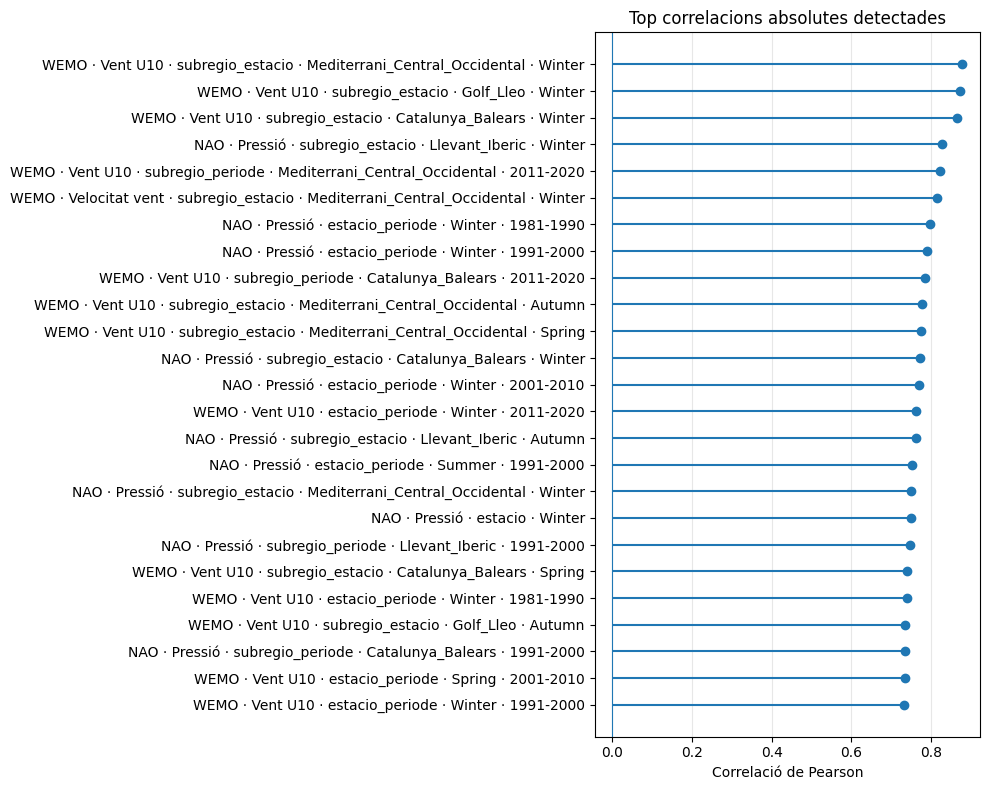

In [7]:
# Gràfic top correlacions

plot_top = top_corr.head(25).copy()

plot_top["etiqueta"] = (
    plot_top["teleconnexio"].str.upper()
    + " · "
    + plot_top["variable"].map(lambda x: label_vars.get(x, x))
    + " · "
    + plot_top["ambit"]
)

# Afegim detalls de grup quan existeixen.
for col in ["subregio", "estacio", "periode"]:
    if col in plot_top.columns:
        plot_top["etiqueta"] = plot_top["etiqueta"] + plot_top[col].apply(
            lambda x: "" if pd.isna(x) else f" · {x}"
        )

plot_top = plot_top.sort_values("pearson_r")

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(plot_top))
ax.hlines(y=y, xmin=0, xmax=plot_top["pearson_r"])
ax.plot(plot_top["pearson_r"], y, "o")
ax.axvline(0, linewidth=0.8)

ax.set_yticks(y)
ax.set_yticklabels(plot_top["etiqueta"])
ax.set_xlabel("Correlació de Pearson")
ax.set_title("Top correlacions absolutes detectades")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "04_top_correlacions.png", dpi=300)
plt.show()

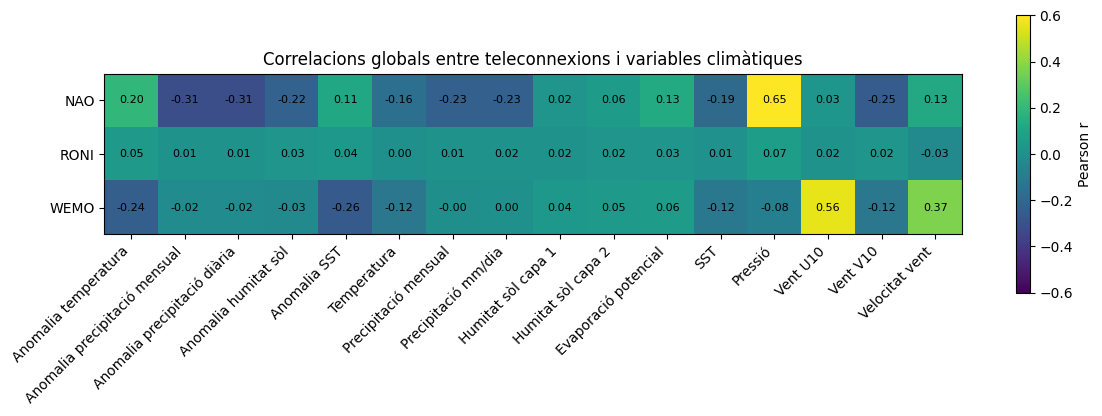

In [8]:
# Matriu resum global

global_corr = corr_exhaustives[corr_exhaustives["ambit"] == "global"].copy()

pivot_global = global_corr.pivot(
    index="teleconnexio",
    columns="variable",
    values="pearson_r"
)

# Reordenem columnes segons la llista original.
pivot_global = pivot_global[[c for c in continuous_vars if c in pivot_global.columns]]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot_global, vmin=-0.6, vmax=0.6)

ax.set_xticks(np.arange(len(pivot_global.columns)))
ax.set_yticks(np.arange(len(pivot_global.index)))

ax.set_xticklabels(
    [label_vars.get(c, c) for c in pivot_global.columns],
    rotation=45,
    ha="right"
)
ax.set_yticklabels([x.upper() for x in pivot_global.index])

for i in range(len(pivot_global.index)):
    for j in range(len(pivot_global.columns)):
        val = pivot_global.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlacions globals entre teleconnexions i variables climàtiques")
plt.colorbar(im, ax=ax, label="Pearson r")

plt.tight_layout()
plt.savefig(FIG / "04_heatmap_correlacions_globals_extens.png", dpi=300)
plt.show()

In [9]:
# Correlacions per subregió i estació

# Aquesta taula és útil per detectar històries locals o estacionals.
corr_sub_est = corr_exhaustives[
    corr_exhaustives["ambit"] == "subregio_estacio"
].copy()

corr_sub_est_top = (
    corr_sub_est
    .query("n >= 40")
    .sort_values("abs_pearson_r", ascending=False)
    .head(50)
)

OUT_SUB_EST = PROC / "04_top_correlacions_subregio_estacio.csv"
corr_sub_est_top.to_csv(OUT_SUB_EST, index=False)

print("Guardat:", OUT_SUB_EST)

corr_sub_est_top[
    [
        "subregio", "estacio", "teleconnexio", "variable",
        "n", "pearson_r", "pearson_p", "pearson_q_fdr"
    ]
].head(25)

Guardat: ../data_processed/04_top_correlacions_subregio_estacio.csv


,subregio,estacio,teleconnexio,variable,n,pearson_r,pearson_p,pearson_q_fdr
9,Mediterrani_Central_Occidental,Winter,wemo,vent_u10,120,0.878347,1.245678e-39,2.874642e-37
13,Golf_Lleo,Winter,wemo,vent_u10,120,0.872308,1.808179e-38,3.741061e-36
18,Catalunya_Balears,Winter,wemo,vent_u10,120,0.864386,4.950813e-37,9.901627e-35
26,Llevant_Iberic,Winter,nao,pressio_nivell_mar,120,0.827421,2.379659e-31,4.326653e-29
34,Mediterrani_Central_Occidental,Winter,wemo,velocitat_vent,120,0.814760,1.044542e-29,1.693852e-27
50,Mediterrani_Central_Occidental,Autumn,wemo,vent_u10,120,0.777348,1.654645e-25,1.985574e-23
53,Mediterrani_Central_Occidental,Spring,wemo,vent_u10,120,0.774879,2.930982e-25,3.448214e-23
59,Catalunya_Balears,Winter,nao,pressio_nivell_mar,120,0.771776,5.951400e-25,6.737434e-23
68,Llevant_Iberic,Autumn,nao,pressio_nivell_mar,120,0.760969,6.445078e-24,6.667322e-22
76,Mediterrani_Central_Occidental,Winter,nao,pressio_nivell_mar,120,0.748670,8.359428e-23,8.222388e-21


In [10]:
# Comparació de fases per variables contínues

rows = []

for tele, phase_col in phase_vars.items():
    phase_a, phase_b = phase_extremes[tele]

    for var in continuous_vars:
        for ambit, group_cols in {
            "global": [],
            "subregio": ["subregio"],
            "estacio": ["estacio"],
            "periode": ["periode"],
            "subregio_estacio": ["subregio", "estacio"],
            "subregio_periode": ["subregio", "periode"],
        }.items():

            if group_cols:
                grouped = df.groupby(group_cols, observed=True)
            else:
                grouped = [((), df)]

            for keys, subset in grouped:
                if not isinstance(keys, tuple):
                    keys = (keys,)

                group_info = dict(zip(group_cols, keys))

                a = subset[subset[phase_col] == phase_a][var].dropna()
                b = subset[subset[phase_col] == phase_b][var].dropna()

                n_a, n_b = len(a), len(b)

                if n_a >= 10 and n_b >= 10:
                    # Mann-Whitney és no paramètric i robust per distribucions no normals.
                    stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
                    d = cohens_d(a, b)
                    diff = b.mean() - a.mean()
                else:
                    stat, p, d, diff = np.nan, np.nan, np.nan, np.nan

                rows.append({
                    "ambit": ambit,
                    **group_info,
                    "teleconnexio": tele,
                    "fase_a": phase_a,
                    "fase_b": phase_b,
                    "variable": var,
                    "n_a": n_a,
                    "n_b": n_b,
                    "mean_a": a.mean() if n_a > 0 else np.nan,
                    "mean_b": b.mean() if n_b > 0 else np.nan,
                    "diff_b_minus_a": diff,
                    "cohens_d": d,
                    "mannwhitney_p": p,
                    "abs_diff": abs(diff) if pd.notna(diff) else np.nan,
                    "abs_d": abs(d) if pd.notna(d) else np.nan,
                })

fase_cont = pd.DataFrame(rows)
fase_cont["mannwhitney_q_fdr"] = fdr_bh(fase_cont["mannwhitney_p"])

fase_cont = fase_cont.sort_values(
    ["abs_d", "abs_diff"],
    ascending=[False, False]
).reset_index(drop=True)

OUT_FASE_CONT = PROC / "04_fases_variables_continues.csv"
fase_cont.to_csv(OUT_FASE_CONT, index=False)

print("Guardat:", OUT_FASE_CONT)
fase_cont.head(30)

Guardat: ../data_processed/04_fases_variables_continues.csv


,ambit,teleconnexio,fase_a,fase_b,variable,n_a,n_b,mean_a,mean_b,diff_b_minus_a,cohens_d,mannwhitney_p,abs_diff,abs_d,subregio,estacio,periode,mannwhitney_q_fdr
0,subregio_estacio,wemo,Negative,Positive,vent_u10,33,43,-0.352639,1.439813,1.792452,3.277294,2.381904e-13,1.792452,3.277294,Golf_Lleo,Winter,NaN,8.720189e-12
1,subregio_estacio,wemo,Negative,Positive,vent_u10,33,43,0.084865,2.519323,2.434459,3.220165,7.598977e-13,2.434459,3.220165,Catalunya_Balears,Winter,NaN,2.486938e-11
2,subregio_estacio,wemo,Negative,Positive,vent_u10,33,43,0.206466,3.670232,3.463766,3.182806,5.590254e-13,3.463766,3.182806,Mediterrani_Central_Occidental,Winter,NaN,1.916658e-11
3,subregio_periode,wemo,Negative,Positive,vent_u10,59,31,-0.196424,2.176961,2.373385,3.053309,2.492430e-13,2.373385,3.053309,Catalunya_Balears,NaN,2011-2020,8.825654e-12
4,subregio_periode,wemo,Negative,Positive,vent_u10,59,31,0.329926,3.273310,2.943384,3.048684,3.617767e-14,2.943384,3.048684,Mediterrani_Central_Occidental,NaN,2011-2020,1.627995e-12
5,subregio_estacio,wemo,Negative,Positive,velocitat_vent,33,43,1.673461,4.374724,2.701262,2.970230,6.519091e-13,2.701262,2.970230,Mediterrani_Central_Occidental,Winter,NaN,2.186773e-11
6,subregio_periode,wemo,Negative,Positive,velocitat_vent,59,31,1.446097,3.853244,2.407146,2.935018,1.597814e-13,2.407146,2.935018,Mediterrani_Central_Occidental,NaN,2011-2020,6.054875e-12
7,subregio_estacio,wemo,Negative,Positive,vent_u10,48,34,-0.149810,1.496082,1.645892,2.321641,2.428072e-12,1.645892,2.321641,Catalunya_Balears,Spring,NaN,7.184433e-11
8,subregio_periode,wemo,Negative,Positive,velocitat_vent,59,31,0.961672,2.834377,1.872705,2.260427,2.518315e-10,1.872705,2.260427,Catalunya_Balears,NaN,2011-2020,5.444026e-09
9,subregio_estacio,wemo,Negative,Positive,vent_u10,48,34,0.336525,2.472360,2.135834,2.245523,3.879496e-12,2.135834,2.245523,Mediterrani_Central_Occidental,Spring,NaN,1.117295e-10


In [11]:
# Top diferències entre fases

top_fases = (
    fase_cont
    .query("n_a >= 20 and n_b >= 20")
    .sort_values("abs_d", ascending=False)
    .copy()
)

OUT_TOP_FASES = PROC / "04_top_diferencies_fases.csv"
top_fases.head(200).to_csv(OUT_TOP_FASES, index=False)

print("Guardat:", OUT_TOP_FASES)

top_fases[
    [
        "ambit", "subregio", "estacio", "periode",
        "teleconnexio", "fase_a", "fase_b", "variable",
        "n_a", "n_b", "mean_a", "mean_b",
        "diff_b_minus_a", "cohens_d", "mannwhitney_p", "mannwhitney_q_fdr"
    ]
].head(30)

Guardat: ../data_processed/04_top_diferencies_fases.csv


,ambit,subregio,estacio,periode,teleconnexio,fase_a,fase_b,variable,n_a,n_b,mean_a,mean_b,diff_b_minus_a,cohens_d,mannwhitney_p,mannwhitney_q_fdr
0,subregio_estacio,Golf_Lleo,Winter,NaN,wemo,Negative,Positive,vent_u10,33,43,-0.352639,1.439813,1.792452,3.277294,2.381904e-13,8.720189e-12
1,subregio_estacio,Catalunya_Balears,Winter,NaN,wemo,Negative,Positive,vent_u10,33,43,0.084865,2.519323,2.434459,3.220165,7.598977e-13,2.486938e-11
2,subregio_estacio,Mediterrani_Central_Occidental,Winter,NaN,wemo,Negative,Positive,vent_u10,33,43,0.206466,3.670232,3.463766,3.182806,5.590254e-13,1.916658e-11
3,subregio_periode,Catalunya_Balears,NaN,2011-2020,wemo,Negative,Positive,vent_u10,59,31,-0.196424,2.176961,2.373385,3.053309,2.492430e-13,8.825654e-12
4,subregio_periode,Mediterrani_Central_Occidental,NaN,2011-2020,wemo,Negative,Positive,vent_u10,59,31,0.329926,3.273310,2.943384,3.048684,3.617767e-14,1.627995e-12
5,subregio_estacio,Mediterrani_Central_Occidental,Winter,NaN,wemo,Negative,Positive,velocitat_vent,33,43,1.673461,4.374724,2.701262,2.970230,6.519091e-13,2.186773e-11
6,subregio_periode,Mediterrani_Central_Occidental,NaN,2011-2020,wemo,Negative,Positive,velocitat_vent,59,31,1.446097,3.853244,2.407146,2.935018,1.597814e-13,6.054875e-12
7,subregio_estacio,Catalunya_Balears,Spring,NaN,wemo,Negative,Positive,vent_u10,48,34,-0.149810,1.496082,1.645892,2.321641,2.428072e-12,7.184433e-11
8,subregio_periode,Catalunya_Balears,NaN,2011-2020,wemo,Negative,Positive,velocitat_vent,59,31,0.961672,2.834377,1.872705,2.260427,2.518315e-10,5.444026e-09
9,subregio_estacio,Mediterrani_Central_Occidental,Spring,NaN,wemo,Negative,Positive,vent_u10,48,34,0.336525,2.472360,2.135834,2.245523,3.879496e-12,1.117295e-10


In [12]:
# Variables booleanes per fase

rows = []

for tele, phase_col in phase_vars.items():
    phase_a, phase_b = phase_extremes[tele]

    for bool_var in bool_vars:
        for ambit, group_cols in {
            "global": [],
            "subregio": ["subregio"],
            "estacio": ["estacio"],
            "periode": ["periode"],
            "subregio_estacio": ["subregio", "estacio"],
            "subregio_periode": ["subregio", "periode"],
        }.items():

            if group_cols:
                grouped = df.groupby(group_cols, observed=True)
            else:
                grouped = [((), df)]

            for keys, subset in grouped:
                if not isinstance(keys, tuple):
                    keys = (keys,)

                group_info = dict(zip(group_cols, keys))

                a = subset[subset[phase_col] == phase_a][bool_var].dropna().astype(bool)
                b = subset[subset[phase_col] == phase_b][bool_var].dropna().astype(bool)

                n_a, n_b = len(a), len(b)
                events_a, events_b = a.sum(), b.sum()

                rate_a = events_a / n_a if n_a > 0 else np.nan
                rate_b = events_b / n_b if n_b > 0 else np.nan
                diff = rate_b - rate_a if pd.notna(rate_a) and pd.notna(rate_b) else np.nan

                # Taula 2x2 per test chi-quadrat.
                if n_a >= 10 and n_b >= 10:
                    table = np.array([
                        [events_a, n_a - events_a],
                        [events_b, n_b - events_b],
                    ])

                    try:
                        chi2, p, _, _ = stats.chi2_contingency(table)
                    except ValueError:
                        p = np.nan
                else:
                    p = np.nan

                rows.append({
                    "ambit": ambit,
                    **group_info,
                    "teleconnexio": tele,
                    "fase_a": phase_a,
                    "fase_b": phase_b,
                    "variable_booleana": bool_var,
                    "n_a": n_a,
                    "n_b": n_b,
                    "events_a": events_a,
                    "events_b": events_b,
                    "rate_a_pct": rate_a * 100 if pd.notna(rate_a) else np.nan,
                    "rate_b_pct": rate_b * 100 if pd.notna(rate_b) else np.nan,
                    "diff_b_minus_a_pct": diff * 100 if pd.notna(diff) else np.nan,
                    "chi2_p": p,
                    "abs_diff_pct": abs(diff * 100) if pd.notna(diff) else np.nan,
                })

fase_bool = pd.DataFrame(rows)
fase_bool["chi2_q_fdr"] = fdr_bh(fase_bool["chi2_p"])

fase_bool = fase_bool.sort_values(
    "abs_diff_pct",
    ascending=False
).reset_index(drop=True)

OUT_BOOL = PROC / "04_booleanes_per_fase.csv"
fase_bool.to_csv(OUT_BOOL, index=False)

print("Guardat:", OUT_BOOL)
fase_bool.head(30)

Guardat: ../data_processed/04_booleanes_per_fase.csv


,ambit,teleconnexio,fase_a,fase_b,variable_booleana,n_a,n_b,events_a,events_b,rate_a_pct,rate_b_pct,diff_b_minus_a_pct,chi2_p,abs_diff_pct,subregio,estacio,periode,chi2_q_fdr
0,subregio_estacio,wemo,Negative,Positive,sol_molt_humit,46,34,24,2,52.173913,5.882353,-46.291560,3.650336e-05,46.291560,Llevant_Iberic,Autumn,NaN,1.213998e-03
1,subregio_estacio,nao,Negative,Positive,mes_molt_sec,66,32,11,20,16.666667,62.500000,45.833333,1.400803e-05,45.833333,Golf_Lleo,Autumn,NaN,6.079355e-04
2,subregio_periode,nao,Negative,Positive,sol_molt_sec,44,53,7,29,15.909091,54.716981,38.807890,1.932889e-04,38.807890,Llevant_Iberic,NaN,1991-2000,4.090696e-03
3,subregio_periode,wemo,Negative,Positive,mes_molt_sec,46,29,17,0,36.956522,0.000000,-36.956522,5.826649e-04,36.956522,Golf_Lleo,NaN,2001-2010,1.012271e-02
4,subregio_estacio,nao,Negative,Positive,sol_molt_humit,40,52,19,6,47.500000,11.538462,-35.961538,3.093039e-04,35.961538,Golf_Lleo,Spring,NaN,5.806932e-03
5,subregio_estacio,wemo,Negative,Positive,sol_molt_humit,33,43,17,7,51.515152,16.279070,-35.236082,2.473481e-03,35.236082,Llevant_Iberic,Winter,NaN,2.908214e-02
6,subregio_estacio,wemo,Negative,Positive,mes_molt_fred,48,34,5,15,10.416667,44.117647,33.700980,1.195022e-03,33.700980,Golf_Lleo,Spring,NaN,1.717292e-02
7,subregio_periode,nao,Negative,Positive,mes_molt_humit,44,53,18,4,40.909091,7.547170,-33.361921,2.495414e-04,33.361921,Golf_Lleo,NaN,1991-2000,4.923156e-03
8,subregio_estacio,wemo,Negative,Positive,mes_molt_fred,46,34,5,15,10.869565,44.117647,33.248082,1.725331e-03,33.248082,Golf_Lleo,Autumn,NaN,2.231429e-02
9,subregio_estacio,wemo,Negative,Positive,sol_molt_humit,46,34,8,17,17.391304,50.000000,32.608696,4.148549e-03,32.608696,Golf_Lleo,Autumn,NaN,4.199053e-02


In [13]:
# Variables booleanes per període i subregió

booleanes_periode = (
    df.groupby(["periode", "subregio"], observed=True)[bool_vars]
    .mean()
    .reset_index()
)

for col in bool_vars:
    booleanes_periode[col] = booleanes_periode[col] * 100

OUT_BOOL_PERIODE = PROC / "04_booleanes_periode_subregio.csv"
booleanes_periode.to_csv(OUT_BOOL_PERIODE, index=False)

print("Guardat:", OUT_BOOL_PERIODE)
booleanes_periode

Guardat: ../data_processed/04_booleanes_periode_subregio.csv


,periode,subregio,mes_molt_calid,mes_molt_fred,mes_molt_sec,mes_molt_humit,sol_molt_sec,sol_molt_humit,episodi_calid_i_sec,episodi_fred_i_humit,episodi_calid_i_sol_sec
0,1981-1990,Llevant_Iberic,8.333333,20.833333,5.000000,10.833333,23.333333,40.000000,0.833333,2.500000,2.500000
1,1981-1990,Catalunya_Balears,5.000000,20.000000,8.333333,10.833333,22.500000,34.166667,0.000000,3.333333,0.833333
2,1981-1990,Golf_Lleo,12.500000,30.000000,23.333333,20.000000,19.166667,26.666667,5.000000,7.500000,3.333333
3,1981-1990,Mediterrani_Central_Occidental,6.666667,20.833333,11.666667,6.666667,28.333333,25.000000,0.833333,5.000000,2.500000
4,1991-2000,Llevant_Iberic,10.833333,18.333333,5.000000,6.666667,35.833333,21.666667,1.666667,3.333333,4.166667
5,1991-2000,Catalunya_Balears,10.833333,20.000000,7.500000,8.333333,24.166667,23.333333,2.500000,2.500000,4.166667
6,1991-2000,Golf_Lleo,16.666667,30.833333,17.500000,23.333333,15.000000,29.166667,5.833333,7.500000,2.500000
7,1991-2000,Mediterrani_Central_Occidental,7.500000,18.333333,7.500000,4.166667,25.833333,23.333333,1.666667,0.833333,2.500000
8,2001-2010,Llevant_Iberic,17.500000,12.500000,2.500000,13.333333,28.333333,30.000000,1.666667,2.500000,10.000000
9,2001-2010,Catalunya_Balears,12.500000,13.333333,5.000000,16.666667,29.166667,28.333333,2.500000,3.333333,6.666667


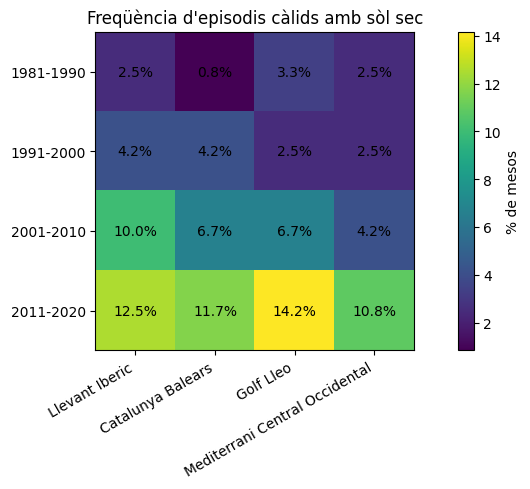

In [14]:
# Heatmap automàtic per variable booleana

bool_focus = "episodi_calid_i_sol_sec"

if bool_focus in bool_vars:
    pivot_bool = booleanes_periode.pivot(
        index="periode",
        columns="subregio",
        values=bool_focus
    )

    pivot_bool = pivot_bool.reindex(index=ordre_periodes, columns=ordre_subregions)

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(pivot_bool)

    ax.set_xticks(np.arange(len(pivot_bool.columns)))
    ax.set_yticks(np.arange(len(pivot_bool.index)))

    ax.set_xticklabels([clean_label(c) for c in pivot_bool.columns], rotation=30, ha="right")
    ax.set_yticklabels(pivot_bool.index)

    for i in range(len(pivot_bool.index)):
        for j in range(len(pivot_bool.columns)):
            val = pivot_bool.iloc[i, j]
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center")

    ax.set_title("Freqüència d'episodis càlids amb sòl sec")
    plt.colorbar(im, ax=ax, label="% de mesos")

    plt.tight_layout()
    plt.savefig(FIG / "04_heatmap_episodi_calid_i_sol_sec.png", dpi=300)
    plt.show()

In [15]:
# Ranking de possibles històries

# Construïm una taula combinada de patrons interessants.
# No és una prova estadística definitiva: és una priorització narrativa.

corr_candidates = top_corr.head(100).copy()
corr_candidates["tipus_resultat"] = "correlacio"
corr_candidates["forca"] = corr_candidates["abs_pearson_r"]
corr_candidates["p_valor"] = corr_candidates["pearson_p"]
corr_candidates["q_fdr"] = corr_candidates["pearson_q_fdr"]
corr_candidates["descripcio"] = (
    corr_candidates["teleconnexio"].str.upper()
    + " vs "
    + corr_candidates["variable"].map(lambda x: label_vars.get(x, x))
    + " · "
    + corr_candidates["ambit"]
)

fase_candidates = top_fases.head(100).copy()
fase_candidates["tipus_resultat"] = "diferencia_fases"
fase_candidates["forca"] = fase_candidates["abs_d"]
fase_candidates["p_valor"] = fase_candidates["mannwhitney_p"]
fase_candidates["q_fdr"] = fase_candidates["mannwhitney_q_fdr"]
fase_candidates["descripcio"] = (
    fase_candidates["teleconnexio"].str.upper()
    + " "
    + fase_candidates["fase_a"].astype(str)
    + " vs "
    + fase_candidates["fase_b"].astype(str)
    + " · "
    + fase_candidates["variable"].map(lambda x: label_vars.get(x, x))
    + " · "
    + fase_candidates["ambit"]
)

bool_candidates = fase_bool.head(100).copy()
bool_candidates["tipus_resultat"] = "diferencia_booleanes"
bool_candidates["forca"] = bool_candidates["abs_diff_pct"] / 100
bool_candidates["p_valor"] = bool_candidates["chi2_p"]
bool_candidates["q_fdr"] = bool_candidates["chi2_q_fdr"]
bool_candidates["descripcio"] = (
    bool_candidates["teleconnexio"].str.upper()
    + " "
    + bool_candidates["fase_a"].astype(str)
    + " vs "
    + bool_candidates["fase_b"].astype(str)
    + " · "
    + bool_candidates["variable_booleana"]
    + " · "
    + bool_candidates["ambit"]
)

histories_candidates = pd.concat(
    [
        corr_candidates[["tipus_resultat", "descripcio", "forca", "p_valor", "q_fdr"]],
        fase_candidates[["tipus_resultat", "descripcio", "forca", "p_valor", "q_fdr"]],
        bool_candidates[["tipus_resultat", "descripcio", "forca", "p_valor", "q_fdr"]],
    ],
    ignore_index=True
)

histories_candidates = histories_candidates.sort_values(
    ["q_fdr", "forca"],
    ascending=[True, False]
).reset_index(drop=True)

OUT_HISTORIES = PROC / "04_candidates_histories.csv"
histories_candidates.to_csv(OUT_HISTORIES, index=False)

print("Guardat:", OUT_HISTORIES)
histories_candidates.head(40)

Guardat: ../data_processed/04_candidates_histories.csv


,tipus_resultat,descripcio,forca,p_valor,q_fdr
0,correlacio,NAO vs Pressió · global,0.649823,8.743969e-231,5.246382e-227
1,diferencia_fases,NAO Negative vs Positive · Pressió · global,1.337725,8.103056e-119,1.750260e-115
2,diferencia_fases,WEMO Negative vs Positive · Vent U10 · global,1.451521,2.038314e-102,2.201379e-99
3,correlacio,NAO vs Pressió · estacio,0.748412,2.779912e-87,5.559823e-84
4,correlacio,WEMO vs Vent U10 · estacio,0.728367,1.642662e-80,2.463994e-77
5,correlacio,NAO vs Pressió · periode,0.710452,5.945136e-75,7.134163e-72
6,correlacio,WEMO vs Vent U10 · subregio,0.705511,1.710854e-73,1.710854e-70
7,correlacio,NAO vs Pressió · estacio,0.690489,3.079597e-69,2.639654e-66
8,correlacio,NAO vs Pressió · subregio,0.683968,1.800723e-67,1.350542e-64
9,correlacio,NAO vs Pressió · periode,0.678771,4.275578e-66,2.850386e-63


## Part B. Validació inicial d'hipòtesis

A partir dels resultats del Notebook 03 i de l'exploració exhaustiva, validem algunes hipòtesis candidates.

Les proves estadístiques no demostren causalitat. Serveixen per comprovar si les associacions observades són consistents i si es mantenen després de considerar múltiples proves.

Hipòtesis inicials:

- H1: La NAO positiva s'associa amb menys precipitació, especialment a l'hivern.
- H2: La NAO positiva s'associa amb menor humitat del sòl.
- H3: La WeMO s'associa amb temperatura i SST, especialment a primavera i tardor.
- H4: RONI/ENSO té un paper més feble que NAO i WeMO.
- H5: Els episodis càlids amb sòl sec augmenten en el període 2011-2020.

In [16]:
# H1 i H2: NAO, precipitació i humitat del sòl

h1h2_rows = []

tests = [
    {
        "hipotesi": "H1",
        "subset_name": "Global",
        "subset": df,
        "x": "nao",
        "y": "anomalia_precipitacio_mensual_mm",
    },
    {
        "hipotesi": "H1",
        "subset_name": "Winter",
        "subset": df[df["estacio"] == "Winter"],
        "x": "nao",
        "y": "anomalia_precipitacio_mensual_mm",
    },
    {
        "hipotesi": "H2",
        "subset_name": "Global",
        "subset": df,
        "x": "nao",
        "y": "anomalia_humitat_sol_capa1",
    },
    {
        "hipotesi": "H2",
        "subset_name": "Winter",
        "subset": df[df["estacio"] == "Winter"],
        "x": "nao",
        "y": "anomalia_humitat_sol_capa1",
    },
]

for t in tests:
    r, p, n = safe_corr(t["subset"], t["x"], t["y"], method="pearson", min_n=20)
    rs, ps, _ = safe_corr(t["subset"], t["x"], t["y"], method="spearman", min_n=20)

    h1h2_rows.append({
        "hipotesi": t["hipotesi"],
        "ambit": t["subset_name"],
        "x": t["x"],
        "y": t["y"],
        "n": n,
        "pearson_r": r,
        "pearson_p": p,
        "spearman_r": rs,
        "spearman_p": ps,
    })

h1h2 = pd.DataFrame(h1h2_rows)
h1h2["pearson_q_fdr"] = fdr_bh(h1h2["pearson_p"])
h1h2["spearman_q_fdr"] = fdr_bh(h1h2["spearman_p"])

OUT_H1H2 = PROC / "04_validacio_h1_h2_nao.csv"
h1h2.to_csv(OUT_H1H2, index=False)

print("Guardat:", OUT_H1H2)
h1h2

Guardat: ../data_processed/04_validacio_h1_h2_nao.csv


,hipotesi,ambit,x,y,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q_fdr,spearman_q_fdr
0,H1,Global,nao,anomalia_precipitacio_mensual_mm,1920,-0.312271,1.075426e-44,-0.292312,3.906849e-39,4.301705e-44,1.562739e-38
1,H1,Winter,nao,anomalia_precipitacio_mensual_mm,480,-0.455861,5.249498e-26,-0.460385,1.483821e-26,1.049900e-25,2.967642e-26
2,H2,Global,nao,anomalia_humitat_sol_capa1,1920,-0.223200,4.209470e-23,-0.211952,6.110730e-21,5.612627e-23,8.147640e-21
3,H2,Winter,nao,anomalia_humitat_sol_capa1,480,-0.387158,1.298850e-18,-0.405945,1.811608e-20,1.298850e-18,1.811608e-20


In [17]:
# H3: WeMO, temperatura i SST

h3_rows = []

for estacio in ["Spring", "Autumn", "Winter", "Summer"]:
    subset = df[df["estacio"] == estacio]

    for y in ["anomalia_temperatura", "anomalia_sst"]:
        r, p, n = safe_corr(subset, "wemo", y, method="pearson", min_n=20)
        rs, ps, _ = safe_corr(subset, "wemo", y, method="spearman", min_n=20)

        h3_rows.append({
            "hipotesi": "H3",
            "estacio": estacio,
            "x": "wemo",
            "y": y,
            "n": n,
            "pearson_r": r,
            "pearson_p": p,
            "spearman_r": rs,
            "spearman_p": ps,
        })

h3 = pd.DataFrame(h3_rows)
h3["pearson_q_fdr"] = fdr_bh(h3["pearson_p"])
h3["spearman_q_fdr"] = fdr_bh(h3["spearman_p"])

OUT_H3 = PROC / "04_validacio_h3_wemo.csv"
h3.to_csv(OUT_H3, index=False)

print("Guardat:", OUT_H3)
h3.sort_values("pearson_r")

Guardat: ../data_processed/04_validacio_h3_wemo.csv


,hipotesi,estacio,x,y,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q_fdr,spearman_q_fdr
3,H3,Autumn,wemo,anomalia_sst,480,-0.468336,1.537609e-27,-0.439542,4.292753e-24,1.230087e-26,3.434203e-23
2,H3,Autumn,wemo,anomalia_temperatura,480,-0.403253,3.398330e-20,-0.390968,5.581357e-19,1.359332e-19,2.232543e-18
0,H3,Spring,wemo,anomalia_temperatura,480,-0.375003,1.786289e-17,-0.356388,8.034350e-16,4.763438e-17,2.142493e-15
1,H3,Spring,wemo,anomalia_sst,480,-0.355504,9.567595e-16,-0.317879,9.888371e-13,1.913519e-15,1.977674e-12
6,H3,Summer,wemo,anomalia_temperatura,480,-0.221387,9.651055e-07,-0.200879,9.213890e-06,1.544169e-06,1.474222e-05
7,H3,Summer,wemo,anomalia_sst,480,-0.178347,8.538861e-05,-0.149429,1.024363e-03,1.138515e-04,1.365817e-03
4,H3,Winter,wemo,anomalia_temperatura,480,0.033835,4.595685e-01,0.055480,2.250259e-01,4.595685e-01,2.250259e-01
5,H3,Winter,wemo,anomalia_sst,480,0.036838,4.206812e-01,0.069492,1.284179e-01,4.595685e-01,1.467634e-01


In [18]:
# H4: comparació de força entre teleconnexions

# Comparem la força mitjana absoluta de les correlacions globals i estacionals.
h4_base = corr_exhaustives[
    corr_exhaustives["ambit"].isin(["global", "estacio", "subregio", "subregio_estacio"])
].copy()

h4_summary = (
    h4_base
    .groupby(["ambit", "teleconnexio"], observed=True)
    .agg(
        mean_abs_r=("abs_pearson_r", "mean"),
        median_abs_r=("abs_pearson_r", "median"),
        max_abs_r=("abs_pearson_r", "max"),
        n_tests=("abs_pearson_r", "count"),
        n_fdr_005=("pearson_q_fdr", lambda x: np.sum(x < 0.05)),
    )
    .reset_index()
    .sort_values(["ambit", "mean_abs_r"], ascending=[True, False])
)

OUT_H4 = PROC / "04_validacio_h4_forca_teleconnexions.csv"
h4_summary.to_csv(OUT_H4, index=False)

print("Guardat:", OUT_H4)
h4_summary

Guardat: ../data_processed/04_validacio_h4_forca_teleconnexions.csv


,ambit,teleconnexio,mean_abs_r,median_abs_r,max_abs_r,n_tests,n_fdr_005
0,estacio,nao,0.201352,0.141797,0.748412,64,35
2,estacio,wemo,0.164331,0.109644,0.728367,64,29
1,estacio,roni,0.076990,0.072510,0.245070,64,16
3,global,nao,0.202467,0.190958,0.649823,16,13
5,global,wemo,0.130853,0.070451,0.557449,16,8
4,global,roni,0.024424,0.020922,0.068605,16,1
6,subregio,nao,0.217379,0.191800,0.683968,64,51
8,subregio,wemo,0.201493,0.160707,0.705511,64,45
7,subregio,roni,0.027178,0.022570,0.079461,64,0
11,subregio_estacio,wemo,0.238094,0.187259,0.878347,256,104


In [19]:
# H5: episodis càlids amb sòl sec i períodes

target = "episodi_calid_i_sol_sec"

rows = []

# Comparació global
comparisons = [("global", df)]

# Comparació per subregió
for subregio in ordre_subregions:
    comparisons.append((f"subregio_{subregio}", df[df["subregio"] == subregio]))

for ambit, subset in comparisons:
    a = subset[subset["periode"] == "1981-1990"][target].dropna().astype(bool)
    b = subset[subset["periode"] == "2011-2020"][target].dropna().astype(bool)

    n_a, n_b = len(a), len(b)
    events_a, events_b = a.sum(), b.sum()

    rate_a = events_a / n_a if n_a > 0 else np.nan
    rate_b = events_b / n_b if n_b > 0 else np.nan
    diff = rate_b - rate_a if pd.notna(rate_a) and pd.notna(rate_b) else np.nan

    if n_a >= 10 and n_b >= 10:
        table = np.array([
            [events_a, n_a - events_a],
            [events_b, n_b - events_b],
        ])

        try:
            chi2, p, _, _ = stats.chi2_contingency(table)
        except ValueError:
            p = np.nan
    else:
        p = np.nan

    subregio_value = np.nan
    if ambit.startswith("subregio_"):
        subregio_value = ambit.replace("subregio_", "")

    rows.append({
        "ambit": ambit,
        "subregio": subregio_value,
        "periode_a": "1981-1990",
        "periode_b": "2011-2020",
        "variable": target,
        "n_a": n_a,
        "n_b": n_b,
        "events_a": events_a,
        "events_b": events_b,
        "rate_a_pct": rate_a * 100 if pd.notna(rate_a) else np.nan,
        "rate_b_pct": rate_b * 100 if pd.notna(rate_b) else np.nan,
        "diff_b_minus_a_pct": diff * 100 if pd.notna(diff) else np.nan,
        "chi2_p": p,
    })

h5 = pd.DataFrame(rows)
h5["chi2_q_fdr"] = fdr_bh(h5["chi2_p"])

OUT_H5 = PROC / "04_validacio_h5_episodis.csv"
h5.to_csv(OUT_H5, index=False)

print("Guardat:", OUT_H5)
h5

Guardat: ../data_processed/04_validacio_h5_episodis.csv


,ambit,subregio,periode_a,periode_b,variable,n_a,n_b,events_a,events_b,rate_a_pct,rate_b_pct,diff_b_minus_a_pct,chi2_p,chi2_q_fdr
0,global,NaN,1981-1990,2011-2020,episodi_calid_i_sol_sec,480,480,11,59,2.291667,12.291667,10.000000,5.401384e-09,2.700692e-08
1,subregio_Llevant_Iberic,Llevant_Iberic,1981-1990,2011-2020,episodi_calid_i_sol_sec,120,120,3,15,2.500000,12.500000,10.000000,7.022257e-03,8.777821e-03
2,subregio_Catalunya_Balears,Catalunya_Balears,1981-1990,2011-2020,episodi_calid_i_sol_sec,120,120,1,14,0.833333,11.666667,10.833333,1.374276e-03,3.435690e-03
3,subregio_Golf_Lleo,Golf_Lleo,1981-1990,2011-2020,episodi_calid_i_sol_sec,120,120,4,17,3.333333,14.166667,10.833333,6.119825e-03,8.777821e-03
4,subregio_Mediterrani_Central_Occidental,Mediterrani_Central_Occidental,1981-1990,2011-2020,episodi_calid_i_sol_sec,120,120,3,13,2.500000,10.833333,8.333333,1.986059e-02,1.986059e-02


In [20]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Regressions simples

# Requereix statsmodels. Si no està instal·lat, pots saltar-la.

try:
    import statsmodels.formula.api as smf

    models = {}

    # H1: precipitació ~ NAO + subregió + estació
    models["H1_precipitacio_nao"] = smf.ols(
        "anomalia_precipitacio_mensual_mm ~ nao + C(subregio) + C(estacio)",
        data=df
    ).fit(cov_type="HC3")

    # H2: humitat sòl ~ NAO + subregió + estació
    models["H2_humitat_nao"] = smf.ols(
        "anomalia_humitat_sol_capa1 ~ nao + C(subregio) + C(estacio)",
        data=df
    ).fit(cov_type="HC3")

    # H3: temperatura ~ WeMO + subregió + estació
    models["H3_temperatura_wemo"] = smf.ols(
        "anomalia_temperatura ~ wemo + C(subregio) + C(estacio)",
        data=df
    ).fit(cov_type="HC3")

    # H3: SST ~ WeMO + subregió + estació
    models["H3_sst_wemo"] = smf.ols(
        "anomalia_sst ~ wemo + C(subregio) + C(estacio)",
        data=df
    ).fit(cov_type="HC3")

    model_rows = []

    for name, model in models.items():
        params = model.params
        pvalues = model.pvalues
        conf = model.conf_int()

        for term in params.index:
            model_rows.append({
                "model": name,
                "term": term,
                "coef": params[term],
                "p_value": pvalues[term],
                "ci_low": conf.loc[term, 0],
                "ci_high": conf.loc[term, 1],
                "r_squared": model.rsquared,
                "n": int(model.nobs),
            })

    regressions = pd.DataFrame(model_rows)
    regressions["q_fdr"] = fdr_bh(regressions["p_value"])

    OUT_REG = PROC / "04_regressions_simples.csv"
    regressions.to_csv(OUT_REG, index=False)

    print("Guardat:", OUT_REG)
    display(regressions)

except ImportError:
    print("statsmodels no està instal·lat. Pots instal·lar-lo amb: %pip install statsmodels")

Guardat: ../data_processed/04_regressions_simples.csv


,model,term,coef,p_value,ci_low,ci_high,r_squared,n,q_fdr
0,H1_precipitacio_nao,Intercept,3.955811e+00,6.024460e-03,1.132801,6.778821,0.104931,1920,2.754039e-02
1,H1_precipitacio_nao,C(subregio)[T.Catalunya_Balears],4.202893e-16,1.000000e+00,-2.849978,2.849978,0.104931,1920,1.000000e+00
2,H1_precipitacio_nao,C(subregio)[T.Golf_Lleo],3.337799e-15,1.000000e+00,-3.733493,3.733493,0.104931,1920,1.000000e+00
3,H1_precipitacio_nao,C(subregio)[T.Mediterrani_Central_Occidental],2.397310e-17,1.000000e+00,-2.793144,2.793144,0.104931,1920,1.000000e+00
4,H1_precipitacio_nao,C(estacio)[T.Spring],-3.177904e+00,6.053897e-02,-6.496542,0.140734,0.104931,1920,1.937247e-01
5,H1_precipitacio_nao,C(estacio)[T.Summer],-5.413483e+00,2.403320e-04,-8.302706,-2.524260,0.104931,1920,1.538125e-03
6,H1_precipitacio_nao,C(estacio)[T.Autumn],-6.502383e+00,1.268294e-03,-10.456525,-2.548240,0.104931,1920,6.764234e-03
7,H1_precipitacio_nao,nao,-5.098242e+00,3.786970e-51,-5.762457,-4.434027,0.104931,1920,1.211830e-49
8,H2_humitat_nao,Intercept,3.548967e-03,1.221894e-01,-0.000951,0.008049,0.053608,1920,3.554602e-01
9,H2_humitat_nao,C(subregio)[T.Catalunya_Balears],-1.159817e-09,9.999996e-01,-0.004572,0.004572,0.053608,1920,1.000000e+00


In [22]:
# Síntesi automàtica de resultats

resum = {
    "n_files": len(df),
    "n_subregions": df["subregio"].nunique(),
    "n_mesos": df["data"].nunique(),
    "top_corr_abs": top_corr.iloc[0]["abs_pearson_r"],
    "top_corr_desc": top_corr.iloc[0]["teleconnexio"] + " vs " + top_corr.iloc[0]["variable"],
    "n_corr_fdr_005": int((corr_exhaustives["pearson_q_fdr"] < 0.05).sum()),
    "n_phase_tests_fdr_005": int((fase_cont["mannwhitney_q_fdr"] < 0.05).sum()),
    "n_bool_tests_fdr_005": int((fase_bool["chi2_q_fdr"] < 0.05).sum()),
}

resum_df = pd.DataFrame([resum])

OUT_RESUM = PROC / "04_resum_exploracio_validacio.csv"
resum_df.to_csv(OUT_RESUM, index=False)

print("Guardat:", OUT_RESUM)
resum_df

Guardat: ../data_processed/04_resum_exploracio_validacio.csv


,n_files,n_subregions,n_mesos,top_corr_abs,top_corr_desc,n_corr_fdr_005,n_phase_tests_fdr_005,n_bool_tests_fdr_005
0,1920,4,480,0.878347,wemo vs vent_u10,1309,684,123


In [23]:
# Rànquing per a la narració

# Veiem que vent i pressió són dominants en top correlació.
# A nivell narratiu volem ficar èmfasi en les variables més tangibles pel públic general

vars_narratives = [
    "anomalia_temperatura",
    "anomalia_precipitacio_mensual_mm",
    "anomalia_humitat_sol_capa1",
    "anomalia_sst",
]

corr_narratives = (
    corr_exhaustives[
        corr_exhaustives["variable"].isin(vars_narratives)
        & corr_exhaustives["ambit"].isin([
            "global",
            "estacio",
            "subregio",
            "subregio_estacio",
        ])
        & (corr_exhaustives["n"] >= 100)
    ]
    .sort_values("abs_pearson_r", ascending=False)
    .copy()
)

OUT_CORR_NARR = PROC / "04_top_correlacions_narratives.csv"
corr_narratives.head(100).to_csv(OUT_CORR_NARR, index=False)

print("Guardat:", OUT_CORR_NARR)

corr_narratives[
    [
        "ambit", "subregio", "estacio", "teleconnexio",
        "variable", "n", "pearson_r", "pearson_p", "pearson_q_fdr"
    ]
].head(30)

Guardat: ../data_processed/04_top_correlacions_narratives.csv


,ambit,subregio,estacio,teleconnexio,variable,n,pearson_r,pearson_p,pearson_q_fdr
338,subregio_estacio,Mediterrani_Central_Occidental,Winter,nao,anomalia_humitat_sol_capa1,120,-0.555398,4.588469e-11,1.429143e-09
405,subregio_estacio,Catalunya_Balears,Winter,nao,anomalia_precipitacio_mensual_mm,120,-0.523242,8.713444e-10,2.273072e-08
431,subregio_estacio,Mediterrani_Central_Occidental,Winter,nao,anomalia_precipitacio_mensual_mm,120,-0.511342,2.400965e-09,5.952806e-08
436,subregio_estacio,Golf_Lleo,Spring,wemo,anomalia_temperatura,120,-0.507885,3.199657e-09,7.804041e-08
444,subregio_estacio,Llevant_Iberic,Winter,wemo,anomalia_precipitacio_mensual_mm,120,-0.504683,4.163099e-09,9.834091e-08
447,subregio_estacio,Mediterrani_Central_Occidental,Autumn,wemo,anomalia_sst,120,-0.502414,5.008111e-09,1.157838e-07
466,subregio_estacio,Catalunya_Balears,Autumn,wemo,anomalia_sst,120,-0.491875,1.161469e-08,2.571519e-07
533,subregio_estacio,Mediterrani_Central_Occidental,Autumn,wemo,anomalia_temperatura,120,-0.468918,6.597252e-08,1.262197e-06
538,estacio,NaN,Autumn,wemo,anomalia_sst,480,-0.468336,1.537609e-27,2.250159e-25
571,subregio_estacio,Golf_Lleo,Autumn,wemo,anomalia_sst,120,-0.457089,1.538103e-07,2.754812e-06


In [24]:
fase_narratives = (
    fase_cont[
        fase_cont["variable"].isin(vars_narratives)
        & fase_cont["ambit"].isin([
            "global",
            "estacio",
            "subregio",
            "subregio_estacio",
        ])
        & (fase_cont["n_a"] >= 20)
        & (fase_cont["n_b"] >= 20)
    ]
    .sort_values("abs_d", ascending=False)
    .copy()
)

OUT_FASE_NARR = PROC / "04_top_diferencies_fases_narratives.csv"
fase_narratives.head(100).to_csv(OUT_FASE_NARR, index=False)

print("Guardat:", OUT_FASE_NARR)

fase_narratives[
    [
        "ambit", "subregio", "estacio", "teleconnexio",
        "fase_a", "fase_b", "variable",
        "n_a", "n_b", "diff_b_minus_a",
        "cohens_d", "mannwhitney_q_fdr"
    ]
].head(30)

Guardat: ../data_processed/04_top_diferencies_fases_narratives.csv


,ambit,subregio,estacio,teleconnexio,fase_a,fase_b,variable,n_a,n_b,diff_b_minus_a,cohens_d,mannwhitney_q_fdr
67,subregio_estacio,Llevant_Iberic,Winter,wemo,Negative,Positive,anomalia_precipitacio_mensual_mm,33,43,-26.247384,-1.402314,5.942077e-06
76,subregio_estacio,Golf_Lleo,Spring,wemo,Negative,Positive,anomalia_temperatura,48,34,-1.453566,-1.348039,5.059202e-06
89,subregio_estacio,Mediterrani_Central_Occidental,Autumn,wemo,Negative,Positive,anomalia_temperatura,46,34,-1.027887,-1.289808,2.614424e-05
90,subregio_estacio,Mediterrani_Central_Occidental,Autumn,wemo,Negative,Positive,anomalia_sst,46,34,-0.932205,-1.289534,1.961771e-05
91,subregio_estacio,Golf_Lleo,Autumn,wemo,Negative,Positive,anomalia_sst,46,34,-1.054395,-1.287569,2.721660e-05
103,subregio_estacio,Catalunya_Balears,Autumn,wemo,Negative,Positive,anomalia_temperatura,46,34,-1.056894,-1.237746,3.819132e-05
109,estacio,NaN,Autumn,wemo,Negative,Positive,anomalia_sst,184,136,-0.881640,-1.198921,2.380626e-17
113,subregio_estacio,Catalunya_Balears,Autumn,wemo,Negative,Positive,anomalia_sst,46,34,-0.796394,-1.173292,1.444140e-04
122,subregio_estacio,Golf_Lleo,Autumn,wemo,Negative,Positive,anomalia_temperatura,46,34,-1.349152,-1.099973,2.674444e-04
125,subregio_estacio,Llevant_Iberic,Autumn,wemo,Negative,Positive,anomalia_humitat_sol_capa1,46,34,-0.048885,-1.092454,1.847599e-04


## Validacions addicionals

Afegim tres validacions complementàries:

1. Models multivariants amb NAO, WeMO i RONI dins el mateix model.
2. Models amb interacció entre teleconnexió i estació.
3. Regressió logística per explicar els episodis càlids amb sòl sec.

També afegim una hipòtesi específica sobre RONI/ENSO i episodis extrems:

- H6: RONI/ENSO podria estar relacionat amb episodis secs, càlids o combinats en alguna subregió o estació concreta.

Aquesta hipòtesi és exploratòria, perquè fins ara RONI ha mostrat una relació global més feble que NAO i WeMO.

In [25]:
# Models multivariants amb NAO + WeMO + RONI

# Models multivariants amb les tres teleconnexions alhora
# Objectiu: veure si NAO, WeMO i RONI mantenen efecte quan competeixen dins el mateix model.

import statsmodels.formula.api as smf

models_multi = {}

formules_multi = {
    "precipitacio": (
        "anomalia_precipitacio_mensual_mm ~ nao + wemo + roni + "
        "C(subregio) + C(estacio)"
    ),
    "humitat_sol": (
        "anomalia_humitat_sol_capa1 ~ nao + wemo + roni + "
        "C(subregio) + C(estacio)"
    ),
    "temperatura": (
        "anomalia_temperatura ~ nao + wemo + roni + "
        "C(subregio) + C(estacio)"
    ),
    "sst": (
        "anomalia_sst ~ nao + wemo + roni + "
        "C(subregio) + C(estacio)"
    ),
}

for name, formula in formules_multi.items():
    models_multi[name] = smf.ols(
        formula=formula,
        data=df
    ).fit(cov_type="HC3")

rows = []

for name, model in models_multi.items():
    conf = model.conf_int()

    for term in model.params.index:
        rows.append({
            "model": name,
            "term": term,
            "coef": model.params[term],
            "p_value": model.pvalues[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "r_squared": model.rsquared,
            "n": int(model.nobs),
        })

multi_reg = pd.DataFrame(rows)
multi_reg["q_fdr"] = fdr_bh(multi_reg["p_value"])

OUT_MULTI = PROC / "04_regressions_multivariants_teleconnexions.csv"
multi_reg.to_csv(OUT_MULTI, index=False)

print("Guardat:", OUT_MULTI)

multi_reg[
    multi_reg["term"].isin(["nao", "wemo", "roni"])
].sort_values(["model", "term"])

Guardat: ../data_processed/04_regressions_multivariants_teleconnexions.csv


,model,term,coef,p_value,ci_low,ci_high,r_squared,n,q_fdr
17,humitat_sol,nao,-0.004648,5.115841e-27,-0.005494,-0.003802,0.056083,1920,5.115841e-26
19,humitat_sol,roni,0.001912,2.302461e-02,0.000263,0.003561,0.056083,1920,7.084495e-02
18,humitat_sol,wemo,-0.000257,7.286225e-01,-0.001709,0.001195,0.056083,1920,1.000000e+00
7,precipitacio,nao,-5.189479,6.227970e-51,-5.867065,-4.511892,0.107029,1920,2.491188e-49
9,precipitacio,roni,1.310395,5.067178e-02,-0.003832,2.624623,0.107029,1920,1.351248e-01
8,precipitacio,wemo,0.381359,5.408658e-01,-0.840955,1.603673,0.107029,1920,9.014430e-01
37,sst,nao,0.062779,6.494896e-12,0.044864,0.080693,0.092076,1920,4.329931e-11
39,sst,roni,0.037917,1.988245e-02,0.006002,0.069831,0.092076,1920,6.627485e-02
38,sst,wemo,-0.195320,5.647640e-36,-0.225892,-0.164749,0.092076,1920,7.530186e-35
27,temperatura,nao,0.140094,1.233875e-23,0.112694,0.167495,0.112969,1920,9.871001e-23


In [26]:
# Coeficients estandarditzats

# Versió estandarditzada opcional
# Serveix per comparar coeficients entre teleconnexions i variables de resposta.

vars_to_z = [
    "nao",
    "wemo",
    "roni",
    "anomalia_precipitacio_mensual_mm",
    "anomalia_humitat_sol_capa1",
    "anomalia_temperatura",
    "anomalia_sst",
]

for col in vars_to_z:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()

models_multi_z = {}

formules_multi_z = {
    "precipitacio_z": (
        "anomalia_precipitacio_mensual_mm_z ~ nao_z + wemo_z + roni_z + "
        "C(subregio) + C(estacio)"
    ),
    "humitat_sol_z": (
        "anomalia_humitat_sol_capa1_z ~ nao_z + wemo_z + roni_z + "
        "C(subregio) + C(estacio)"
    ),
    "temperatura_z": (
        "anomalia_temperatura_z ~ nao_z + wemo_z + roni_z + "
        "C(subregio) + C(estacio)"
    ),
    "sst_z": (
        "anomalia_sst_z ~ nao_z + wemo_z + roni_z + "
        "C(subregio) + C(estacio)"
    ),
}

for name, formula in formules_multi_z.items():
    models_multi_z[name] = smf.ols(
        formula=formula,
        data=df
    ).fit(cov_type="HC3")

rows = []

for name, model in models_multi_z.items():
    conf = model.conf_int()

    for term in model.params.index:
        rows.append({
            "model": name,
            "term": term,
            "coef_estandarditzat": model.params[term],
            "p_value": model.pvalues[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "r_squared": model.rsquared,
            "n": int(model.nobs),
        })

multi_reg_z = pd.DataFrame(rows)
multi_reg_z["q_fdr"] = fdr_bh(multi_reg_z["p_value"])

OUT_MULTI_Z = PROC / "04_regressions_multivariants_estandarditzades.csv"
multi_reg_z.to_csv(OUT_MULTI_Z, index=False)

print("Guardat:", OUT_MULTI_Z)

multi_reg_z[
    multi_reg_z["term"].isin(["nao_z", "wemo_z", "roni_z"])
].sort_values(["model", "term"])

Guardat: ../data_processed/04_regressions_multivariants_estandarditzades.csv


,model,term,coef_estandarditzat,p_value,ci_low,ci_high,r_squared,n,q_fdr
17,humitat_sol_z,nao_z,-0.244063,5.115841e-27,-0.288505,-0.199621,0.056083,1920,5.115841e-26
19,humitat_sol_z,roni_z,0.049782,2.302461e-02,0.006856,0.092708,0.056083,1920,7.084495e-02
18,humitat_sol_z,wemo_z,-0.007989,7.286225e-01,-0.053117,0.037140,0.056083,1920,1.000000e+00
7,precipitacio_z,nao_z,-0.342038,6.227970e-51,-0.386697,-0.297378,0.107029,1920,2.491188e-49
9,precipitacio_z,roni_z,0.042816,5.067178e-02,-0.000125,0.085757,0.107029,1920,1.351248e-01
8,precipitacio_z,wemo_z,0.014875,5.408658e-01,-0.032802,0.062553,0.107029,1920,9.406361e-01
37,sst_z,nao_z,0.153000,6.494896e-12,0.109340,0.196661,0.092076,1920,4.329931e-11
39,sst_z,roni_z,0.045810,1.988245e-02,0.007251,0.084369,0.092076,1920,6.627485e-02
38,sst_z,wemo_z,-0.281715,5.647640e-36,-0.325809,-0.237621,0.092076,1920,7.530186e-35
27,temperatura_z,nao_z,0.238867,1.233875e-23,0.192148,0.285587,0.112969,1920,9.871001e-23


In [27]:
# Models amb interacció entre teleconnexió i estació
# Objectiu: validar si la relació depèn de l'època de l'any.

models_interaccio = {}

formules_interaccio = {
    "H1_precipitacio_nao_estacio": (
        "anomalia_precipitacio_mensual_mm ~ nao * C(estacio) + C(subregio)"
    ),
    "H2_humitat_nao_estacio": (
        "anomalia_humitat_sol_capa1 ~ nao * C(estacio) + C(subregio)"
    ),
    "H3_temperatura_wemo_estacio": (
        "anomalia_temperatura ~ wemo * C(estacio) + C(subregio)"
    ),
    "H3_sst_wemo_estacio": (
        "anomalia_sst ~ wemo * C(estacio) + C(subregio)"
    ),
}

for name, formula in formules_interaccio.items():
    models_interaccio[name] = smf.ols(
        formula=formula,
        data=df
    ).fit(cov_type="HC3")

rows = []

for name, model in models_interaccio.items():
    conf = model.conf_int()

    for term in model.params.index:
        rows.append({
            "model": name,
            "term": term,
            "coef": model.params[term],
            "p_value": model.pvalues[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "r_squared": model.rsquared,
            "n": int(model.nobs),
        })

interaccio_reg = pd.DataFrame(rows)
interaccio_reg["q_fdr"] = fdr_bh(interaccio_reg["p_value"])

OUT_INTERACCIO = PROC / "04_regressions_interaccio_estacio.csv"
interaccio_reg.to_csv(OUT_INTERACCIO, index=False)

print("Guardat:", OUT_INTERACCIO)

# Mostrem només termes principals i interaccions
interaccio_reg[
    interaccio_reg["term"].str.contains("nao|wemo", regex=True)
].sort_values(["model", "term"])

Guardat: ../data_processed/04_regressions_interaccio_estacio.csv


,model,term,coef,p_value,ci_low,ci_high,r_squared,n,q_fdr
7,H1_precipitacio_nao_estacio,nao,-6.334863,3.027388e-27,-7.483250,-5.186477,0.129205,1920,1.332051e-25
10,H1_precipitacio_nao_estacio,nao:C(estacio)[T.Autumn],-0.871035,3.830404e-01,-2.828138,1.086069,0.129205,1920,8.025608e-01
8,H1_precipitacio_nao_estacio,nao:C(estacio)[T.Spring],0.711979,4.767817e-01,-1.249337,2.673296,0.129205,1920,8.660831e-01
9,H1_precipitacio_nao_estacio,nao:C(estacio)[T.Summer],5.570704,1.825871e-15,4.197778,6.943630,0.129205,1920,2.008458e-14
18,H2_humitat_nao_estacio,nao,-0.005628,1.677746e-18,-0.006885,-0.004371,0.068358,1920,2.460694e-17
21,H2_humitat_nao_estacio,nao:C(estacio)[T.Autumn],0.000686,5.690310e-01,-0.001674,0.003046,0.068358,1920,8.715284e-01
19,H2_humitat_nao_estacio,nao:C(estacio)[T.Spring],-0.001694,1.885134e-01,-0.004218,0.000831,0.068358,1920,4.365573e-01
20,H2_humitat_nao_estacio,nao:C(estacio)[T.Summer],0.005156,4.376638e-08,0.003310,0.007001,0.068358,1920,2.751030e-07
40,H3_sst_wemo_estacio,wemo,0.020118,4.517068e-01,-0.032277,0.072514,0.099528,1920,8.641347e-01
43,H3_sst_wemo_estacio,wemo:C(estacio)[T.Autumn],-0.377534,3.387367e-22,-0.453912,-0.301157,0.099528,1920,7.452208e-21


**Nota important per interpretar la cel·la anterior:**

Com que l’ordre de les estacions és:

ordre_estacions = ["Winter", "Spring", "Summer", "Autumn"]

la categoria base és Winter. Per tant:

    el coeficient nao representa l’efecte de NAO a Winter;
    nao:C(estacio)[T.Spring] indica quant canvia l’efecte respecte a Winter;
    igual per wemo.

In [28]:
# Regressió logística per H5
# Objectiu: comprovar si el període 2011-2020 manté una associació positiva
# amb els episodis càlids amb sòl sec controlant per subregió i estació.

target = "episodi_calid_i_sol_sec"

df_logit = df.copy()
df_logit[target] = df_logit[target].astype(int)

models_logit = {}

formules_logit = {
    "H5_periode_subregio": (
        f"{target} ~ C(periode) + C(subregio)"
    ),
    "H5_periode_subregio_estacio": (
        f"{target} ~ C(periode) + C(subregio) + C(estacio)"
    ),
    "H5_complet_teleconnexions": (
        f"{target} ~ C(periode) + nao + wemo + roni + C(subregio) + C(estacio)"
    ),
}

for name, formula in formules_logit.items():
    models_logit[name] = smf.logit(
        formula=formula,
        data=df_logit
    ).fit(disp=False)

rows = []

for name, model in models_logit.items():
    conf = model.conf_int()

    for term in model.params.index:
        coef = model.params[term]
        rows.append({
            "model": name,
            "term": term,
            "coef_logit": coef,
            "odds_ratio": np.exp(coef),
            "p_value": model.pvalues[term],
            "or_ci_low": np.exp(conf.loc[term, 0]),
            "or_ci_high": np.exp(conf.loc[term, 1]),
            "pseudo_r2": model.prsquared,
            "n": int(model.nobs),
        })

logit_h5 = pd.DataFrame(rows)
logit_h5["q_fdr"] = fdr_bh(logit_h5["p_value"])

OUT_LOGIT_H5 = PROC / "04_logit_h5_episodis_calid_sol_sec.csv"
logit_h5.to_csv(OUT_LOGIT_H5, index=False)

print("Guardat:", OUT_LOGIT_H5)

logit_h5.sort_values(["model", "p_value"]).head(40)

Guardat: ../data_processed/04_logit_h5_episodis_calid_sol_sec.csv


,model,term,coef_logit,odds_ratio,p_value,or_ci_low,or_ci_high,pseudo_r2,n,q_fdr
17,H5_complet_teleconnexions,Intercept,-4.228067,0.014581,2.294700e-24,0.006463,0.032893,0.100040,1920,3.442050e-23
20,H5_complet_teleconnexions,C(periode)[T.2011-2020],1.787781,5.976175,1.750253e-07,3.055805,11.687482,0.100040,1920,8.751264e-07
27,H5_complet_teleconnexions,nao,0.266943,1.305965,1.436971e-05,1.157588,1.473362,0.100040,1920,6.158446e-05
19,H5_complet_teleconnexions,C(periode)[T.2001-2010],1.384074,3.991129,1.418423e-04,1.956431,8.141923,0.100040,1920,5.319084e-04
28,H5_complet_teleconnexions,wemo,-0.263850,0.768088,4.840527e-03,0.639290,0.922837,0.100040,1920,1.320144e-02
29,H5_complet_teleconnexions,roni,0.312570,1.366933,6.055759e-03,1.093486,1.708761,0.100040,1920,1.513940e-02
25,H5_complet_teleconnexions,C(estacio)[T.Summer],0.646571,1.908984,3.108636e-02,1.060543,3.436185,0.100040,1920,7.173776e-02
23,H5_complet_teleconnexions,C(subregio)[T.Mediterrani_Central_Occidental],-0.424015,0.654414,1.308354e-01,0.377537,1.134345,0.100040,1920,2.405326e-01
26,H5_complet_teleconnexions,C(estacio)[T.Autumn],0.442990,1.557356,1.548628e-01,0.845905,2.867174,0.100040,1920,2.571571e-01
24,H5_complet_teleconnexions,C(estacio)[T.Spring],0.413797,1.512550,1.628662e-01,0.845880,2.704649,0.100040,1920,2.571571e-01


## H6. RONI/ENSO i episodis secs o extrems

Comprovem si RONI/ENSO està associat amb episodis extrems, i sobretot:

- mesos molt secs;
- mesos molt càlids;
- sòl molt sec;
- episodis càlids i secs;
- episodis càlids amb sòl sec.

Aquesta anàlisi és exploratòria i es mira tant globalment com per subregió i estació.

In [29]:
# H6A: correlació entre RONI i variables booleanes extremes

extreme_bool_vars = [
    "mes_molt_calid",
    "mes_molt_fred",
    "mes_molt_sec",
    "mes_molt_humit",
    "sol_molt_sec",
    "sol_molt_humit",
    "episodi_calid_i_sec",
    "episodi_fred_i_humit",
    "episodi_calid_i_sol_sec",
]

extreme_bool_vars = [v for v in extreme_bool_vars if v in df.columns]

grouping_h6 = {
    "global": [],
    "subregio": ["subregio"],
    "estacio": ["estacio"],
    "subregio_estacio": ["subregio", "estacio"],
    "periode": ["periode"],
    "subregio_periode": ["subregio", "periode"],
}

rows = []

for ambit, group_cols in grouping_h6.items():
    if group_cols:
        grouped = df.groupby(group_cols, observed=True)
    else:
        grouped = [((), df)]

    for keys, subset in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)

        group_info = dict(zip(group_cols, keys))

        for var in extreme_bool_vars:
            tmp = subset[["roni", var]].dropna().copy()
            tmp[var] = tmp[var].astype(int)

            n = len(tmp)
            n_events = tmp[var].sum()

            if n >= 30 and tmp[var].nunique() > 1:
                r, p = stats.pointbiserialr(tmp[var], tmp["roni"])
            else:
                r, p = np.nan, np.nan

            rows.append({
                "ambit": ambit,
                **group_info,
                "teleconnexio": "roni",
                "variable_booleana": var,
                "n": n,
                "n_events": n_events,
                "event_rate_pct": n_events / n * 100 if n > 0 else np.nan,
                "pointbiserial_r": r,
                "p_value": p,
                "abs_r": abs(r) if pd.notna(r) else np.nan,
            })

h6_roni_bool_corr = pd.DataFrame(rows)
h6_roni_bool_corr["q_fdr"] = fdr_bh(h6_roni_bool_corr["p_value"])

h6_roni_bool_corr = h6_roni_bool_corr.sort_values(
    ["abs_r", "n"],
    ascending=[False, False]
).reset_index(drop=True)

OUT_H6_CORR = PROC / "04_h6_roni_booleanes_correlacio.csv"
h6_roni_bool_corr.to_csv(OUT_H6_CORR, index=False)

print("Guardat:", OUT_H6_CORR)

h6_roni_bool_corr.head(30)

Guardat: ../data_processed/04_h6_roni_booleanes_correlacio.csv


,ambit,teleconnexio,variable_booleana,n,n_events,event_rate_pct,pointbiserial_r,p_value,abs_r,subregio,estacio,periode,q_fdr
0,subregio_estacio,roni,mes_molt_humit,120,12,10.000000,-0.276814,0.002209,0.276814,Mediterrani_Central_Occidental,Spring,NaN,0.123682
1,subregio_estacio,roni,mes_molt_humit,120,11,9.166667,0.255749,0.004813,0.255749,Golf_Lleo,Summer,NaN,0.171504
2,subregio_periode,roni,episodi_calid_i_sol_sec,120,14,11.666667,0.242614,0.007587,0.242614,Catalunya_Balears,NaN,2011-2020,0.228788
3,subregio_estacio,roni,sol_molt_sec,120,29,24.166667,-0.238009,0.008852,0.238009,Golf_Lleo,Autumn,NaN,0.242088
4,subregio_periode,roni,mes_molt_calid,120,49,40.833333,0.231620,0.010914,0.231620,Golf_Lleo,NaN,2011-2020,0.255252
5,subregio_estacio,roni,sol_molt_sec,120,40,33.333333,-0.230387,0.011358,0.230387,Llevant_Iberic,Autumn,NaN,0.255252
6,subregio_estacio,roni,mes_molt_humit,120,25,20.833333,-0.229408,0.011721,0.229408,Golf_Lleo,Spring,NaN,0.255252
7,subregio_estacio,roni,episodi_calid_i_sec,120,2,1.666667,0.223517,0.014128,0.223517,Llevant_Iberic,Autumn,NaN,0.276900
8,subregio_periode,roni,episodi_calid_i_sec,120,2,1.666667,0.219917,0.015801,0.219917,Llevant_Iberic,NaN,2011-2020,0.294954
9,subregio_periode,roni,episodi_fred_i_humit,120,2,1.666667,-0.202415,0.026614,0.202415,Mediterrani_Central_Occidental,NaN,2001-2010,0.395097


In [30]:
# H6B: diferència de proporcions entre La Niña i El Niño per variables extremes

rows = []

phase_col = "fase_enso"
fase_a = "La Nina"
fase_b = "El Nino"

for ambit, group_cols in grouping_h6.items():
    if group_cols:
        grouped = df.groupby(group_cols, observed=True)
    else:
        grouped = [((), df)]

    for keys, subset in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)

        group_info = dict(zip(group_cols, keys))

        for var in extreme_bool_vars:
            a = subset[subset[phase_col] == fase_a][var].dropna().astype(bool)
            b = subset[subset[phase_col] == fase_b][var].dropna().astype(bool)

            n_a, n_b = len(a), len(b)
            events_a, events_b = a.sum(), b.sum()

            rate_a = events_a / n_a if n_a > 0 else np.nan
            rate_b = events_b / n_b if n_b > 0 else np.nan
            diff = rate_b - rate_a if pd.notna(rate_a) and pd.notna(rate_b) else np.nan

            if n_a >= 10 and n_b >= 10:
                table = np.array([
                    [events_a, n_a - events_a],
                    [events_b, n_b - events_b],
                ])

                try:
                    chi2, p, _, _ = stats.chi2_contingency(table)
                except ValueError:
                    p = np.nan
            else:
                p = np.nan

            rows.append({
                "ambit": ambit,
                **group_info,
                "teleconnexio": "roni",
                "fase_a": fase_a,
                "fase_b": fase_b,
                "variable_booleana": var,
                "n_a": n_a,
                "n_b": n_b,
                "events_a": events_a,
                "events_b": events_b,
                "rate_a_pct": rate_a * 100 if pd.notna(rate_a) else np.nan,
                "rate_b_pct": rate_b * 100 if pd.notna(rate_b) else np.nan,
                "diff_el_nino_minus_la_nina_pct": diff * 100 if pd.notna(diff) else np.nan,
                "chi2_p": p,
                "abs_diff_pct": abs(diff * 100) if pd.notna(diff) else np.nan,
            })

h6_roni_bool_fases = pd.DataFrame(rows)
h6_roni_bool_fases["q_fdr"] = fdr_bh(h6_roni_bool_fases["chi2_p"])

h6_roni_bool_fases = h6_roni_bool_fases.sort_values(
    ["abs_diff_pct", "n_a", "n_b"],
    ascending=[False, False, False]
).reset_index(drop=True)

OUT_H6_FASES = PROC / "04_h6_roni_booleanes_fases.csv"
h6_roni_bool_fases.to_csv(OUT_H6_FASES, index=False)

print("Guardat:", OUT_H6_FASES)

h6_roni_bool_fases.head(30)

Guardat: ../data_processed/04_h6_roni_booleanes_fases.csv


,ambit,teleconnexio,fase_a,fase_b,variable_booleana,n_a,n_b,events_a,events_b,rate_a_pct,rate_b_pct,diff_el_nino_minus_la_nina_pct,chi2_p,abs_diff_pct,subregio,estacio,periode,q_fdr
0,subregio_estacio,roni,La Nina,El Nino,mes_molt_fred,27,31,0,8,0.000000,25.806452,25.806452,0.013844,25.806452,Catalunya_Balears,Summer,NaN,0.532987
1,subregio_estacio,roni,La Nina,El Nino,mes_molt_humit,34,30,13,4,38.235294,13.333333,-24.901961,0.049149,24.901961,Golf_Lleo,Spring,NaN,0.925030
2,subregio_estacio,roni,La Nina,El Nino,sol_molt_sec,39,37,18,8,46.153846,21.621622,-24.532225,0.044288,24.532225,Llevant_Iberic,Autumn,NaN,0.925030
3,subregio_estacio,roni,La Nina,El Nino,mes_molt_humit,34,30,8,0,23.529412,0.000000,-23.529412,0.013833,23.529412,Mediterrani_Central_Occidental,Spring,NaN,0.532987
4,subregio_estacio,roni,La Nina,El Nino,sol_molt_sec,34,30,8,14,23.529412,46.666667,23.137255,0.092751,23.137255,Mediterrani_Central_Occidental,Spring,NaN,1.000000
5,subregio_estacio,roni,La Nina,El Nino,mes_molt_fred,27,31,0,7,0.000000,22.580645,22.580645,0.025805,22.580645,Mediterrani_Central_Occidental,Summer,NaN,0.827900
6,subregio_estacio,roni,La Nina,El Nino,sol_molt_sec,39,37,14,5,35.897436,13.513514,-22.383922,0.046868,22.383922,Golf_Lleo,Autumn,NaN,0.925030
7,subregio_estacio,roni,La Nina,El Nino,sol_molt_humit,34,30,14,6,41.176471,20.000000,-21.176471,0.120257,21.176471,Llevant_Iberic,Spring,NaN,1.000000
8,subregio_estacio,roni,La Nina,El Nino,sol_molt_humit,34,30,14,6,41.176471,20.000000,-21.176471,0.120257,21.176471,Catalunya_Balears,Spring,NaN,1.000000
9,subregio_periode,roni,La Nina,El Nino,mes_molt_calid,45,24,15,13,33.333333,54.166667,20.833333,0.155276,20.833333,Golf_Lleo,NaN,2011-2020,1.000000


In [31]:
# H6C: models logístics específics per RONI i episodis extrems

h6_targets = [
    "mes_molt_sec",
    "mes_molt_calid",
    "sol_molt_sec",
    "episodi_calid_i_sec",
    "episodi_calid_i_sol_sec",
]

h6_targets = [v for v in h6_targets if v in df.columns]

rows = []

for target in h6_targets:
    tmp = df.copy()
    tmp[target] = tmp[target].astype(int)

    formula = f"{target} ~ roni + C(subregio) + C(estacio) + C(periode)"

    try:
        model = smf.logit(
            formula=formula,
            data=tmp
        ).fit(disp=False)

        conf = model.conf_int()

        for term in model.params.index:
            rows.append({
                "target": target,
                "term": term,
                "coef_logit": model.params[term],
                "odds_ratio": np.exp(model.params[term]),
                "p_value": model.pvalues[term],
                "or_ci_low": np.exp(conf.loc[term, 0]),
                "or_ci_high": np.exp(conf.loc[term, 1]),
                "pseudo_r2": model.prsquared,
                "n": int(model.nobs),
            })

    except Exception as e:
        rows.append({
            "target": target,
            "term": "ERROR",
            "coef_logit": np.nan,
            "odds_ratio": np.nan,
            "p_value": np.nan,
            "or_ci_low": np.nan,
            "or_ci_high": np.nan,
            "pseudo_r2": np.nan,
            "n": len(tmp),
            "error": str(e),
        })

h6_roni_logit = pd.DataFrame(rows)
h6_roni_logit["q_fdr"] = fdr_bh(h6_roni_logit["p_value"])

OUT_H6_LOGIT = PROC / "04_h6_roni_logit_extrems.csv"
h6_roni_logit.to_csv(OUT_H6_LOGIT, index=False)

print("Guardat:", OUT_H6_LOGIT)

h6_roni_logit[
    h6_roni_logit["term"] == "roni"
].sort_values("p_value")

Guardat: ../data_processed/04_h6_roni_logit_extrems.csv


,target,term,coef_logit,odds_ratio,p_value,or_ci_low,or_ci_high,pseudo_r2,n,q_fdr
21,mes_molt_calid,roni,0.232143,1.261300,0.000993,1.098504,1.448223,0.085878,1920,0.003035
54,episodi_calid_i_sol_sec,roni,0.337739,1.401775,0.002740,1.123846,1.748436,0.070657,1920,0.007534
43,episodi_calid_i_sec,roni,0.331033,1.392406,0.012335,1.074397,1.804543,0.120912,1920,0.030837
32,sol_molt_sec,roni,-0.038540,0.962193,0.512798,0.857311,1.079906,0.016456,1920,0.575590
10,mes_molt_sec,roni,0.037109,1.037807,0.647825,0.885043,1.216937,0.135548,1920,0.685199


In [32]:
# Resum automàtic H6

h6_corr_top = h6_roni_bool_corr.head(10).copy()

h6_fases_top = (
    h6_roni_bool_fases
    .query("q_fdr < 0.05")
    .head(10)
    .copy()
)

h6_logit_roni = (
    h6_roni_logit[h6_roni_logit["term"] == "roni"]
    .sort_values("p_value")
    .copy()
)

OUT_H6_LOGIT_RONI = PROC / "04_h6_resum_roni_extrems.csv"
h6_logit_roni.to_csv(OUT_H6_LOGIT_RONI, index=False)

print("Top correlacions RONI vs booleanes extremes")
display(h6_corr_top)

print("Diferències de fase ENSO significatives després de FDR")
display(h6_fases_top)

print("Models logístics: efecte de RONI")
display(h6_logit_roni)

Top correlacions RONI vs booleanes extremes


,ambit,teleconnexio,variable_booleana,n,n_events,event_rate_pct,pointbiserial_r,p_value,abs_r,subregio,estacio,periode,q_fdr
0,subregio_estacio,roni,mes_molt_humit,120,12,10.000000,-0.276814,0.002209,0.276814,Mediterrani_Central_Occidental,Spring,NaN,0.123682
1,subregio_estacio,roni,mes_molt_humit,120,11,9.166667,0.255749,0.004813,0.255749,Golf_Lleo,Summer,NaN,0.171504
2,subregio_periode,roni,episodi_calid_i_sol_sec,120,14,11.666667,0.242614,0.007587,0.242614,Catalunya_Balears,NaN,2011-2020,0.228788
3,subregio_estacio,roni,sol_molt_sec,120,29,24.166667,-0.238009,0.008852,0.238009,Golf_Lleo,Autumn,NaN,0.242088
4,subregio_periode,roni,mes_molt_calid,120,49,40.833333,0.231620,0.010914,0.231620,Golf_Lleo,NaN,2011-2020,0.255252
5,subregio_estacio,roni,sol_molt_sec,120,40,33.333333,-0.230387,0.011358,0.230387,Llevant_Iberic,Autumn,NaN,0.255252
6,subregio_estacio,roni,mes_molt_humit,120,25,20.833333,-0.229408,0.011721,0.229408,Golf_Lleo,Spring,NaN,0.255252
7,subregio_estacio,roni,episodi_calid_i_sec,120,2,1.666667,0.223517,0.014128,0.223517,Llevant_Iberic,Autumn,NaN,0.276900
8,subregio_periode,roni,episodi_calid_i_sec,120,2,1.666667,0.219917,0.015801,0.219917,Llevant_Iberic,NaN,2011-2020,0.294954
9,subregio_periode,roni,episodi_fred_i_humit,120,2,1.666667,-0.202415,0.026614,0.202415,Mediterrani_Central_Occidental,NaN,2001-2010,0.395097


Diferències de fase ENSO significatives després de FDR


,ambit,teleconnexio,fase_a,fase_b,variable_booleana,n_a,n_b,events_a,events_b,rate_a_pct,rate_b_pct,diff_el_nino_minus_la_nina_pct,chi2_p,abs_diff_pct,subregio,estacio,periode,q_fdr
14,estacio,roni,La Nina,El Nino,mes_molt_fred,108,124,6,31,5.555556,25.000000,19.444444,0.000116,19.444444,NaN,Summer,NaN,0.022254
20,estacio,roni,La Nina,El Nino,mes_molt_humit,136,120,31,5,22.794118,4.166667,-18.627451,0.000042,18.627451,NaN,Spring,NaN,0.016033


Models logístics: efecte de RONI


,target,term,coef_logit,odds_ratio,p_value,or_ci_low,or_ci_high,pseudo_r2,n,q_fdr
21,mes_molt_calid,roni,0.232143,1.261300,0.000993,1.098504,1.448223,0.085878,1920,0.003035
54,episodi_calid_i_sol_sec,roni,0.337739,1.401775,0.002740,1.123846,1.748436,0.070657,1920,0.007534
43,episodi_calid_i_sec,roni,0.331033,1.392406,0.012335,1.074397,1.804543,0.120912,1920,0.030837
32,sol_molt_sec,roni,-0.038540,0.962193,0.512798,0.857311,1.079906,0.016456,1920,0.575590
10,mes_molt_sec,roni,0.037109,1.037807,0.647825,0.885043,1.216937,0.135548,1920,0.685199
